# Selección de aumentos para TTA

En este notebook replicamos la Sección 4.3 de la tesis Real-Time Object Detection Uncertainty Quantification using Augmented Images for Autonomous Vehicles de ElHayani (2024) sobre el modelo YOLO26 y el dataset KITTI.

In [1]:
import random
import sys
from pathlib import Path

import cv2
import numpy as np
import torch
from PIL import Image
from torchvision import transforms as T
from ultralytics import YOLO

REPO_ROOT = Path.cwd().resolve()
if REPO_ROOT.name == "notebooks":
    REPO_ROOT = REPO_ROOT.parent
assert (REPO_ROOT / "pyproject.toml").exists(), f"Unexpected repo root: {REPO_ROOT}"
sys.path.insert(0, str(REPO_ROOT / "src"))

KITTI_VAL_DIR = REPO_ROOT / "data" / "kitti" / "images" / "val"
CHECKPOINT = REPO_ROOT / "results" / "runs" / "detect" / "finetune_stage2_unfrozen" / "weights" / "best.pt"
assert CHECKPOINT.exists(), f"Checkpoint not found: {CHECKPOINT}"

SAMPLE_SIZE = 500
IOU_MATCH_THRES = 0.70   
FN_THRESHOLD = 25.0      
SEED = 0

random.seed(SEED)
np.random.seed(SEED)

In [2]:
model = YOLO(str(CHECKPOINT))

all_val_images = sorted(KITTI_VAL_DIR.glob("*.png"))
sample_paths = random.sample(all_val_images, SAMPLE_SIZE)
print(f"Sampled {len(sample_paths)} / {len(all_val_images)} val images (seed={SEED})")

Sampled 500 / 1496 val images (seed=0)


Los 14 aumentos candidatos de la tesis (Sección 4.3), rotación excluida como en la tesis. Los que tienen parámetros explícitos en la tesis los usan tal cual; los "sin parámetros" (contraste, gamma, ruido gaussiano/Poisson) llevan un valor por defecto razonable elegido por mí, marcado en el comentario — la tesis no fija esos valores, así que no debe darse por hecho que son "los correctos", son un punto de partida a revisar si algún resultado sale raro.

In [ ]:
def gaussian_blur(img: np.ndarray) -> np.ndarray:
    """Kernel size in [5,30] (odd), sigma in [0.1,5]."""
    k = random.randrange(5, 31, 2)
    sigma = random.uniform(0.1, 5.0)
    return cv2.GaussianBlur(img, (k, k), sigma)


def random_value_change(img: np.ndarray) -> np.ndarray:
    """Thesis 4.3: +/- a random value on 30% of pixels. Magnitude not given by the thesis --
    +/-50 (uint8 scale) chosen as a reasonable default, flag for review."""
    out = img.astype(np.int16)
    mask = np.random.rand(*img.shape[:2]) < 0.30
    delta = np.random.randint(-50, 51, size=int(mask.sum()))
    out[mask] += delta[:, None] if img.ndim == 3 else delta
    return np.clip(out, 0, 255).astype(np.uint8)


_color_jitter = T.ColorJitter(brightness=0.5, hue=0.3)  # thesis 4.3 params, exact match

def color_jitter(img: np.ndarray) -> np.ndarray:
    rgb = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    return cv2.cvtColor(np.array(_color_jitter(rgb)), cv2.COLOR_RGB2BGR)


_elastic = T.ElasticTransform(alpha=(50.0, 200.0))  # thesis 4.3: random alpha in [50,200]

def elastic_transform(img: np.ndarray) -> np.ndarray:
    rgb = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    return cv2.cvtColor(np.array(_elastic(rgb)), cv2.COLOR_RGB2BGR)


def posterize(img: np.ndarray) -> np.ndarray:
    """Thesis 4.3: bits in [1,4]."""
    bits = random.randint(1, 4)
    shift = 8 - bits
    return ((img >> shift) << shift).astype(np.uint8)


def salt_and_pepper(img: np.ndarray) -> np.ndarray:
    """Thesis 4.3: 30% of pixels, half salt (255) half pepper (0)."""
    out = img.copy()
    mask = np.random.rand(*img.shape[:2]) < 0.30
    salt = np.random.rand(*img.shape[:2]) < 0.5
    out[mask & salt] = 255
    out[mask & ~salt] = 0
    return out


def random_noise(img: np.ndarray) -> np.ndarray:
    """Thesis 4.3: variance 0.9, applied on a [0,1]-normalized image (0.9 on the raw 0-255
    scale would be imperceptible) -- our own scale interpretation, check empirically if this
    ends up with a degenerate (near 0% or near 100%) false-negative rate."""
    normed = img.astype(np.float32) / 255.0
    noise = np.random.normal(0, np.sqrt(0.9), img.shape).astype(np.float32)
    return np.clip((normed + noise) * 255.0, 0, 255).astype(np.uint8)


def gaussian_noise(img: np.ndarray) -> np.ndarray:
    """Parameterless in the thesis -- sigma=45 (uint8 scale), noticeable but not
    aggressive (within imgaug's AdditiveGaussianNoise typical range, ~0-51)."""
    noise = np.random.normal(0, 45, img.shape).astype(np.float32)
    return np.clip(img.astype(np.float32) + noise, 0, 255).astype(np.uint8)


def poisson_noise(img: np.ndarray) -> np.ndarray:
    """Parameterless in the thesis -- reimplemented per imgaug's direct convention:
    Poisson(lam) sampled directly on the uint8 scale, random sign per pixel, lam=20
    ('visible noise' per imgaug's own guidance). Replaces the previous [0,1]-normalized
    approach (scale=4.0), the likely cause of the suspicious 82.66% FN smoke-test result."""
    lam = 20.0
    noise = np.random.poisson(lam, size=img.shape).astype(np.float32)
    sign = np.random.choice([-1.0, 1.0], size=img.shape)
    return np.clip(img.astype(np.float32) + sign * noise, 0, 255).astype(np.uint8)


def contrast_enhance(img: np.ndarray) -> np.ndarray:
    """Parameterless in the thesis -- factor=1.30."""
    return cv2.convertScaleAbs(img, alpha=1.30, beta=0)


def gamma_correction(img: np.ndarray) -> np.ndarray:
    """Parameterless in the thesis -- gamma=1.25, noticeable but moderate."""
    lut = ((np.arange(256) / 255.0) ** (1 / 1.25) * 255).astype(np.uint8)
    return cv2.LUT(img, lut)


def flip_horizontal(img: np.ndarray) -> np.ndarray:
    return cv2.flip(img, 1)


def flip_vertical(img: np.ndarray) -> np.ndarray:
    return cv2.flip(img, 0)


def equalize(img: np.ndarray) -> np.ndarray:
    """Per-channel histogram equalization (colour-space handling not specified by the thesis)."""
    return cv2.merge([cv2.equalizeHist(c) for c in cv2.split(img)])


AUGMENTATIONS = {
    "image_blurring": gaussian_blur,
    "random_value_changing": random_value_change,
    "colour_jitter": color_jitter,
    "elastic_transform": elastic_transform,
    "posterize": posterize,
    "salt_and_pepper": salt_and_pepper,
    "random_noise": random_noise,
    "gaussian_noise": gaussian_noise,
    "poisson_noise": poisson_noise,
    "contrast_enhancing": contrast_enhance,
    "gamma_correction": gamma_correction,
    "flip_horizontal": flip_horizontal,
    "flip_vertical": flip_vertical,
    "equalization": equalize,
}

# Augmentations that move pixel locations -- boxes need coordinate reversal before IoU
# matching (thesis 4.3: "Apart from rotation and flipping, all augmentations keep pixels
# in the same locations").
GEOMETRIC_AUGS = {"flip_horizontal", "flip_vertical"}

Implementación directa de la Sección 4.3: IoU≥70% para considerar correspondencia, clasificación en correct/wrong/not_detected/unmatched. El emparejamiento greedy por IoU descendente es mi elección — la tesis no especifica el algoritmo de emparejamiento exacto, greedy es la opción estándar más simple.

In [4]:
def box_iou(a: np.ndarray, b: np.ndarray) -> np.ndarray:
    """Pairwise IoU. a: (N,4) xyxy, b: (M,4) xyxy -> (N,M)."""
    area_a = (a[:, 2] - a[:, 0]) * (a[:, 3] - a[:, 1])
    area_b = (b[:, 2] - b[:, 0]) * (b[:, 3] - b[:, 1])
    lt = np.maximum(a[:, None, :2], b[None, :, :2])
    rb = np.minimum(a[:, None, 2:], b[None, :, 2:])
    wh = np.clip(rb - lt, 0, None)
    inter = wh[..., 0] * wh[..., 1]
    return inter / (area_a[:, None] + area_b[None, :] - inter + 1e-9)


def flip_boxes(boxes_xyxy: np.ndarray, img_w: int, img_h: int, aug_name: str) -> np.ndarray:
    out = boxes_xyxy.copy()
    if aug_name == "flip_horizontal":
        out[:, [0, 2]] = img_w - boxes_xyxy[:, [2, 0]]
    elif aug_name == "flip_vertical":
        out[:, [1, 3]] = img_h - boxes_xyxy[:, [3, 1]]
    return out


def classify_matches(boxes_before, cls_before, boxes_after, cls_after, iou_thres=IOU_MATCH_THRES):
    """Thesis 4.3 categories: correct / wrong / not_detected (FN) / unmatched (FP)."""
    n, m = len(boxes_before), len(boxes_after)
    counts = {"correct": 0, "wrong": 0, "not_detected": 0, "unmatched": 0}
    if n == 0 and m == 0:
        return counts
    if n == 0:
        counts["unmatched"] = m
        return counts
    if m == 0:
        counts["not_detected"] = n
        return counts

    iou = box_iou(boxes_before, boxes_after)
    matched_before, matched_after = set(), set()
    order = np.dstack(np.unravel_index(np.argsort(-iou, axis=None), iou.shape))[0]
    for i, j in order:
        if iou[i, j] < iou_thres:
            break
        if i in matched_before or j in matched_after:
            continue
        matched_before.add(i)
        matched_after.add(j)
        counts["correct" if cls_before[i] == cls_after[j] else "wrong"] += 1

    counts["not_detected"] = n - len(matched_before)
    counts["unmatched"] = m - len(matched_after)
    return counts

Aquí se ejecuta la inferencia real: una pasada base (sin aumentar) sobre toda la muestra, y una pasada por cada uno de los 14 aumentos. Se agrupa en lotes (batch_size) para aprovechar que model.predict() acepta listas de imágenes — igual que en las Pruebas de fine-tuning, la GPU es el cuello de botella, no la carga de datos, así que procesar en lote reduce overhead.

In [5]:
def run_batched_predict(model, images, batch_size=16):
    results = []
    for i in range(0, len(images), batch_size):
        results.extend(model.predict(images[i:i + batch_size], verbose=False, device=0))
    return results


images_bgr = [cv2.imread(str(p)) for p in sample_paths]
baseline_results = run_batched_predict(model, images_bgr)

fn_stats = {name: {"not_detected": 0, "total_before": 0} for name in AUGMENTATIONS}

for name, aug_fn in AUGMENTATIONS.items():
    aug_images = [aug_fn(img) for img in images_bgr]
    aug_results = run_batched_predict(model, aug_images)

    for base_res, aug_res in zip(baseline_results, aug_results):
        boxes_before = base_res.boxes.xyxy.cpu().numpy()
        cls_before = base_res.boxes.cls.cpu().numpy()
        boxes_after = aug_res.boxes.xyxy.cpu().numpy()
        cls_after = aug_res.boxes.cls.cpu().numpy()

        if name in GEOMETRIC_AUGS:
            h, w = base_res.orig_shape
            boxes_after = flip_boxes(boxes_after, w, h, name)

        counts = classify_matches(boxes_before, cls_before, boxes_after, cls_after)
        fn_stats[name]["not_detected"] += counts["not_detected"]
        fn_stats[name]["total_before"] += len(boxes_before)

    print(f"{name}: done")

image_blurring: done
random_value_changing: done
colour_jitter: done
elastic_transform: done
posterize: done
salt_and_pepper: done
random_noise: done
gaussian_noise: done
poisson_noise: done
contrast_enhancing: done
gamma_correction: done
flip_horizontal: done
flip_vertical: done
equalization: done


Cálculo del %FN por aumento y aplicación del umbral 25% como punto de partida.

contrast_enhancing          4.78% FN  (n_boxes=2804)
gamma_correction            6.38% FN  (n_boxes=2804)
flip_horizontal            15.37% FN  (n_boxes=2804)
equalization               18.72% FN  (n_boxes=2804)
elastic_transform          23.68% FN  (n_boxes=2804)
colour_jitter              24.36% FN  (n_boxes=2804)
random_value_changing      30.28% FN  (n_boxes=2804)
image_blurring             34.02% FN  (n_boxes=2804)
posterize                  34.66% FN  (n_boxes=2804)
poisson_noise              34.99% FN  (n_boxes=2804)
gaussian_noise             77.53% FN  (n_boxes=2804)
flip_vertical              99.57% FN  (n_boxes=2804)
salt_and_pepper            99.61% FN  (n_boxes=2804)
random_noise              100.00% FN  (n_boxes=2804)


C:\Users\alber\AppData\Local\Temp\ipykernel_23776\2311858186.py:17: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(names, rotation=45, ha="right")


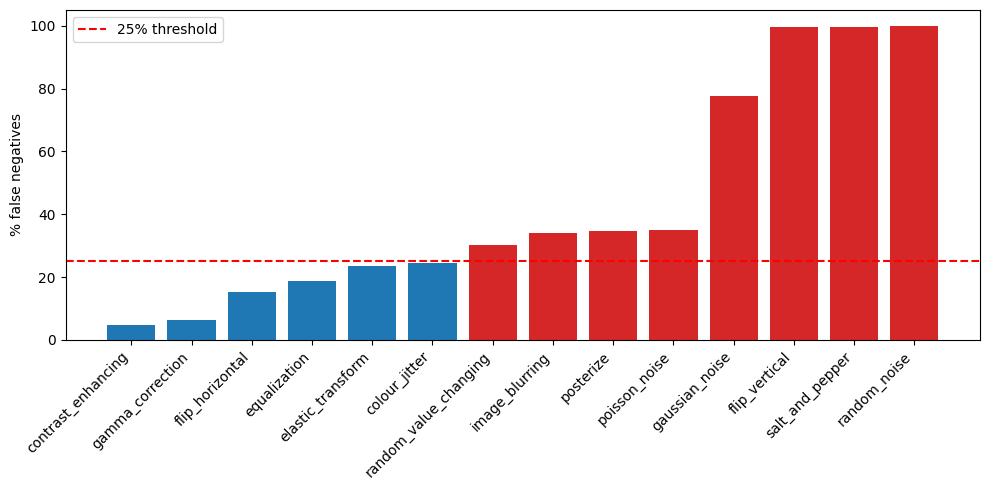

In [6]:
import matplotlib.pyplot as plt

fn_percent = {
    name: 100.0 * stats["not_detected"] / max(stats["total_before"], 1)
    for name, stats in fn_stats.items()
}
sorted_items = sorted(fn_percent.items(), key=lambda kv: kv[1])

for name, pct in sorted_items:
    print(f"{name:25s} {pct:6.2f}% FN  (n_boxes={fn_stats[name]['total_before']})")

names, pcts = zip(*sorted_items)
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(names, pcts, color=["tab:blue" if p <= FN_THRESHOLD else "tab:red" for p in pcts])
ax.axhline(FN_THRESHOLD, color="red", linestyle="--", label=f"{FN_THRESHOLD:.0f}% threshold")
ax.set_ylabel("% false negatives")
ax.set_xticklabels(names, rotation=45, ha="right")
ax.legend()
plt.tight_layout()
plt.show()

In [7]:
kept = [name for name, pct in fn_percent.items() if pct <= FN_THRESHOLD]
discarded = [name for name, pct in fn_percent.items() if pct > FN_THRESHOLD]

print(f"Kept ({len(kept)}): {kept}")
print(f"Discarded ({len(discarded)}): {discarded}")

Kept (6): ['colour_jitter', 'elastic_transform', 'contrast_enhancing', 'gamma_correction', 'flip_horizontal', 'equalization']
Discarded (8): ['image_blurring', 'random_value_changing', 'posterize', 'salt_and_pepper', 'random_noise', 'gaussian_noise', 'poisson_noise', 'flip_vertical']
